# DLAV Project - Phase 1

In this notebook we will train a very simple planner on data coming from a driving simulator. You are given a dash cam image of the current state of the driving vehicle, and the past positions of this vehicle, and you are asked to plan its future route.

This notebook will take you through steps on building this planner to solve the task. The full skeleton of the code together with some very simple implementations of each module are provided for your comfort. So all the cells below will run without you needing to change anything, but the performance won't be very good. You are asked to re-implement and play with most of the modules yourself to be able to have better performance.

P.S. to enable fast compute, you should use GPUs in google colab. The code works without GPUs, but it'll be much faster to use GPUs, specially if your model gets bigger and bigger! You can utilize Colab's GPUs by selecting "Change runtime type" in the Runtime menu on top of this page. There you can select "T4 GPU". This would restart your runtime, so you'll need to re-run everything from the top.

The first step is to prepare the data. The setup cell below detects the project root, adds the repository to `sys.path`, and checks whether the datasets already exist in `data/`. Missing archives are downloaded only once and extracted into `data/`.

In [ ]:
import importlib.util
import subprocess
import sys
import zipfile
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not find the project root containing 'src/' and 'data/'.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test_public"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUTS_DIR / "phase1_model.pth"
SUBMISSION_PATH = OUTPUTS_DIR / "submission_phase1.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def has_pkl_files(directory: Path) -> bool:
    return directory.is_dir() and any(directory.glob("*.pkl"))

def ensure_gdown():
    if importlib.util.find_spec("gdown") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown
    return gdown

def ensure_dataset(name: str, file_id: str, zip_name: str, target_dir: Path) -> None:
    zip_path = DATA_DIR / zip_name
    if has_pkl_files(target_dir):
        print(f"{name}: found extracted files in {target_dir.relative_to(PROJECT_ROOT)}, skipping download.")
        return

    if not zip_path.exists():
        gdown = ensure_gdown()
        download_url = f"https://drive.google.com/uc?id={file_id}"
        print(f"{name}: downloading {zip_path.relative_to(PROJECT_ROOT)}...")
        gdown.download(download_url, str(zip_path), quiet=False)
    else:
        print(f"{name}: found archive {zip_path.relative_to(PROJECT_ROOT)}, skipping download.")

    print(f"{name}: extracting {zip_path.name} into {DATA_DIR.relative_to(PROJECT_ROOT)}...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

    if not has_pkl_files(target_dir):
        raise FileNotFoundError(f"{name}: no .pkl files found in {target_dir}")

    print(f"{name}: ready in {target_dir.relative_to(PROJECT_ROOT)}")

DATASETS = {
    "train": {
        "file_id": "1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr",
        "zip_name": "dlav_train.zip",
        "target_dir": TRAIN_DIR,
    },
    "val": {
        "file_id": "1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu",
        "zip_name": "dlav_val.zip",
        "target_dir": VAL_DIR,
    },
    "test_public": {
        "file_id": "1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV",
        "zip_name": "dlav_test_public.zip",
        "target_dir": TEST_DIR,
    },
}

for name, config in DATASETS.items():
    ensure_dataset(name, **config)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Outputs directory: {OUTPUTS_DIR}")

Downloading...
From (original): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr
From (redirected): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr&confirm=t&uuid=9d8ff83c-61b3-496c-8bbe-55a604138fc9
To: /content/dlav_train.zip
100%|██████████| 439M/439M [00:07<00:00, 60.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu
From (redirected): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu&confirm=t&uuid=694a440b-94b4-4ea0-8287-e9c4e8117d1d
To: /content/dlav_val.zip
100%|██████████| 87.8M/87.8M [00:01<00:00, 46.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV
From (redirected): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV&confirm=t&uuid=98134051-f45a-49eb-80b2-aea096cf474b
To: /content/dlav_test_public.zip
100%|██████████| 86.6M/86.6M [00:00<00:00, 104MB/s]


Now lets load the data and visualize the first few examples to see what we are dealing with!

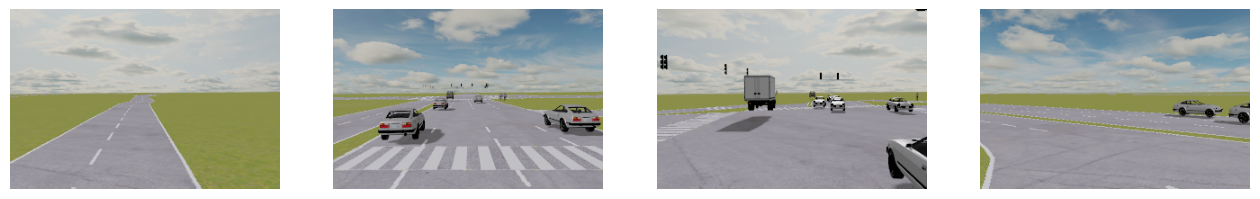

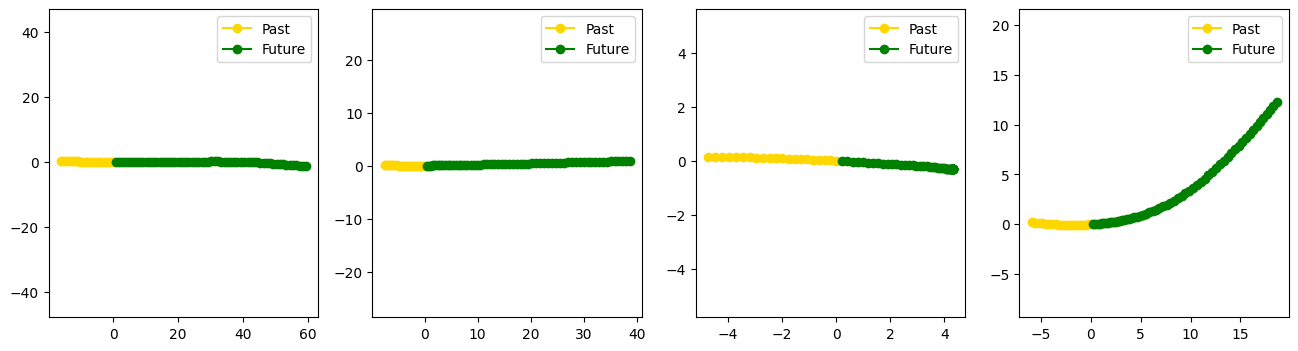

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random

k = 4
train_sample_files = list(TRAIN_DIR.glob("*.pkl"))
if not train_sample_files:
    raise FileNotFoundError(f"No training files found in {TRAIN_DIR}")

data = []
for sample_path in random.choices(train_sample_files, k=k):
    with open(sample_path, "rb") as f:
        data.append(pickle.load(f))

# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].imshow(data[i]["camera"])
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].plot(data[i]["sdc_history_feature"][:, 0], data[i]["sdc_history_feature"][:, 1], "o-", color="gold", label="Past")
    axis[i].plot(data[i]["sdc_future_feature"][:, 0], data[i]["sdc_future_feature"][:, 1], "o-", color="green", label="Future")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now its time to make our hands dirty!

In the following cells we will define the classes we need to do a proper training in pytorch.

1. We will start with defining a Dataset class which loads the data and does some basic preprocessing. You can further process this data as you see fit.
2. We then define the logger which receives training metrics and logs and prints/visualizes them. Having a good logger means a lot when dealing with neural network training! The logger implemented here is very simple and we strongly suggest you try other ways of visualizing your losses and metrics. Be creative ;)
3. We then proceed with defining the core part of the pipeline, the model. You are going to mainly implement the model yourself, but we have provided a very simple model so that the code runs as is so that you can see how the whole framework runs all in all.
4. Finally, we define the training funciton which contains the training loop, and we call it to see the magic! You'll need to also do a lot of changes here, from the batch size and learning rate, to adding augmentation schemes and schedulers, etc.

In [ ]:
from src.dataset import DrivingDataset


In [ ]:
from src.logger import Logger


In [ ]:
from src.model import DrivingPlanner


In [ ]:
from src.train import train


In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

train_files = sorted(TRAIN_DIR.glob("*.pkl"), key=lambda path: int(path.stem))
val_files = sorted(VAL_DIR.glob("*.pkl"), key=lambda path: int(path.stem))

if not train_files:
    raise FileNotFoundError(f"No training files found in {TRAIN_DIR}")
if not val_files:
    raise FileNotFoundError(f"No validation files found in {VAL_DIR}")

train_dataset = DrivingDataset(train_files)
val_dataset = DrivingDataset(val_files)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2)

model = DrivingPlanner()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

logger = Logger()

train(model, train_loader, val_loader, optimizer, logger, num_epochs=50)


By running the code above, you have trained your first model!
What do you observe in terms of train and val losses? What is this phenomenon called? (Explain in a few lines below)




This model is very simple and does not necessarilly yield the optimal performance. You are asked to implement your own neural network architecture. You can use convolution networks, vision transformers, etc. Try with different architectures, different model sizes, and other hyper parameters such as learning rate and batch size to find the best performance. Other ideas could be to use augmentation thechniques to boost the performance, adding learning rate schedulers, and exploring other loss functions.

Once you are happy with your model, continue with the rest of the notebook to save your checkpoint in `outputs/phase1_model.pth` and also visualize some plans coming from the model. The last cell will create `outputs/submission_phase1.csv`, which you can submit to the leaderboard to see your results on the testing set.

In [ ]:
# save the model
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

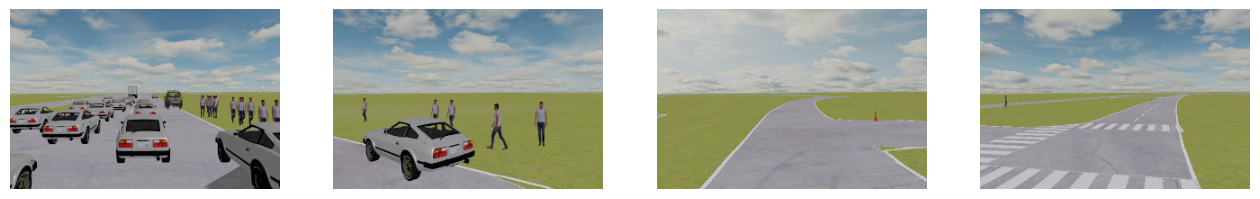

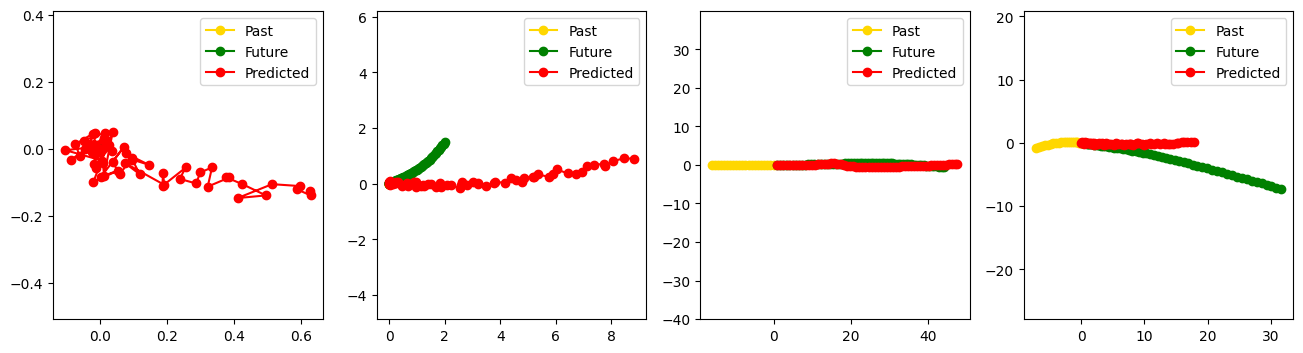

In [ ]:
val_batch_zero = next(iter(val_loader))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
camera = val_batch_zero['camera'].to(device)
history = val_batch_zero['history'].to(device)
future = val_batch_zero['future'].to(device)

model.eval()
with torch.no_grad():
    pred_future = model(camera, history)

camera = camera.cpu().numpy()
history = history.cpu().numpy()
future = future.cpu().numpy()
pred_future = pred_future.cpu().numpy()
k=4
selected_indices = random.choices(np.arange(len(camera)), k=k)
# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].imshow(camera[idx].transpose(1, 2, 0)/255)
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].plot(history[idx, :, 0], history[idx, :, 1], "o-", color="gold", label="Past")
    axis[i].plot(future[idx, :, 0], future[idx, :, 1], "o-", color="green", label="Future")
    axis[i].plot(pred_future[idx, :, 0], pred_future[idx, :, 1], "o-", color="red", label="Predicted")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now we run our model on the test set once to get the predicted plans and save them for submission. Notice that the ground truth plans are removed for the test set, so you can not calculate the ADE metric on the test set yourself and need to submit to the leaderboard. The last cell writes `outputs/submission_phase1.csv`.

In [ ]:
with open(TEST_DIR / "0.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
# Note the absence of sdc_future_feature

dict_keys(['camera', 'depth', 'driving_command', 'sdc_history_feature', 'semantic_label'])


In [ ]:
import pandas as pd
test_files = sorted(TEST_DIR.glob("*.pkl"), key=lambda path: int(path.stem))
if not test_files:
    raise FileNotFoundError(f"No test files found in {TEST_DIR}")

test_dataset = DrivingDataset(test_files, test=True)
test_loader = DataLoader(test_dataset, batch_size=250, num_workers=2)
model.eval()
all_plans = []
with torch.no_grad():
    for batch in test_loader:
        camera = batch['camera'].to(device)
        history = batch['history'].to(device)

        pred_future = model(camera, history)
        all_plans.append(pred_future.cpu().numpy()[..., :2])
all_plans = np.concatenate(all_plans, axis=0)

# Now save the plans as a csv file
pred_xy = all_plans[..., :2]  # shape: (total_samples, T, 2)

# Flatten to (total_samples, T*2)
total_samples, T, D = pred_xy.shape
pred_xy_flat = pred_xy.reshape(total_samples, T * D)

# Build a DataFrame with an ID column
ids = np.arange(total_samples)
df_xy = pd.DataFrame(pred_xy_flat)
df_xy.insert(0, "id", ids)

# Column names: id, x_1, y_1, x_2, y_2, ..., x_T, y_T
new_col_names = ["id"]
for t in range(1, T + 1):
    new_col_names.append(f"x_{t}")
    new_col_names.append(f"y_{t}")
df_xy.columns = new_col_names

# Save to CSV
df_xy.to_csv(SUBMISSION_PATH, index=False)

print(f"Submission saved to {SUBMISSION_PATH}")
print(f"Shape of df_xy: {df_xy.shape}")

Shape of df_xy: (1000, 121)
